# 9 WorkFlow Analista Jr

## Versión destinada a evaluar el dataset

### 9.1 Objetivo

1. Analizar el comportamiento del sistema bancario durante los meses de pandemia a traves del atributo clase_ternaria y los valores BAJA+1 y BAJA+2.

2. Realizar una comparación estadística de escenarios en los que pretendemos maximizar ganancias del modelo predictivo quitando meses anómalos del período estudiado.

### 9.2 Inicializacion

Esta parte se debe correr con el runtime en lenguaje **R** Ir al menu, Runtime -> Change Runtime Type -> Runtime type -> R

limpio el ambiente de R

In [1]:
format(Sys.time(), "%a %b %d %X %Y")

[1] "Fri Sep 11 18:22:03 2026"

In [2]:
# limpio la memoria
rm(list=ls(all.names=TRUE)) # remove all objects
gc(full=TRUE, verbose=FALSE) # garbage collection

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,671179,35.9,1479525,79.1,1479525,79.1
Vcells,1242588,9.5,8388608,64.0,1978697,15.1


In [3]:
require("data.table")

if( !require("R.utils")) install.packages("R.utils")
require("R.utils")

Loading required package: data.table


Attaching package: ‘data.table’


The following object is masked from ‘package:base’:

    %notin%


Loading required package: R.utils

Loading required package: R.oo

Loading required package: R.methodsS3

R.methodsS3 v1.8.2 (2022-06-13 22:00:14 UTC) successfully loaded. See ?R.methodsS3 for help.

R.oo v1.27.1 (2025-05-02 21:00:05 UTC) successfully loaded. See ?R.oo for help.


Attaching package: ‘R.oo’


The following object is masked from ‘package:R.methodsS3’:

    throw


The following objects are masked from ‘package:methods’:

    getClasses, getMethods


The following objects are masked from ‘package:base’:

    attach, detach, load, save


R.utils v2.13.0 (2025-02-24 21:20:02 UTC) successfully loaded. See ?R.utils for help.


Attaching package: ‘R.utils’


The following object is masked from ‘package:utils’:

    timestamp


The following objects are masked from ‘package:base’:

    cat, commandArgs, getOption, isOpen, nullfile, parse, u

#### Parametros

In [4]:
PARAM <- list()
PARAM$semilla_primigenia <- 700001

PARAM$experimento <- 1000
PARAM$dataset <- "analistajr_competencia_2026.csv.gz"

#### Carpeta del Experimento

In [5]:
# carpeta de trabajo

setwd("/content/buckets/b1/exp")
experimento_folder <- paste0("WF", PARAM$experimento)
dir.create(experimento_folder, showWarnings=FALSE)
setwd( paste0("/content/buckets/b1/exp/", experimento_folder ))

### 9.3  Lectura del dataset

In [6]:
# lectura del dataset
dataset <- fread(paste0("/content/datasets/", PARAM$dataset))

### 9.4  Análisis estadístico de los valores BAJA+1 y BAJA+2

In [7]:
# ============================================================
# ANALISIS TEMPORAL DE BAJA+1 Y BAJA+2
# ============================================================

tb_clases_mes <- dataset[
  !is.na(clase_ternaria),
  .(
    total = .N,
    baja1 = sum(clase_ternaria == "BAJA+1"),
    baja2 = sum(clase_ternaria == "BAJA+2")
  ),
  by = foto_mes
]

tb_clases_mes[
  ,
  `:=`(
    pct_baja1 = 100 * baja1 / total,
    pct_baja2 = 100 * baja2 / total
  )
]

setorder(tb_clases_mes, foto_mes)

tb_clases_mes

foto_mes,total,baja1,baja2,pct_baja1,pct_baja2
<int>,<int>,<int>,<int>,<dbl>,<dbl>
201901,24956,133,135,0.5329380,0.5409521
201902,25165,136,132,0.5404331,0.5245380
201903,25254,133,148,0.5266492,0.5860458
201904,25346,149,132,0.5878640,0.5207922
201905,25460,133,124,0.5223881,0.4870385
201906,25755,127,117,0.4931081,0.4542807
201907,26040,117,126,0.4493088,0.4838710
201908,26443,127,103,0.4802783,0.3895171
201909,26767,107,118,0.3997460,0.4408413


In [8]:
# ============================================================
# Acondiciono el campo mes para mejorar la gráfica
# ============================================================
tb_grafico <- copy(tb_clases_mes[foto_mes <= 202107])

tb_grafico[, fecha := as.Date(
  paste0(substr(foto_mes, 1, 4), "-",
         substr(foto_mes, 5, 6), "-01")
)]

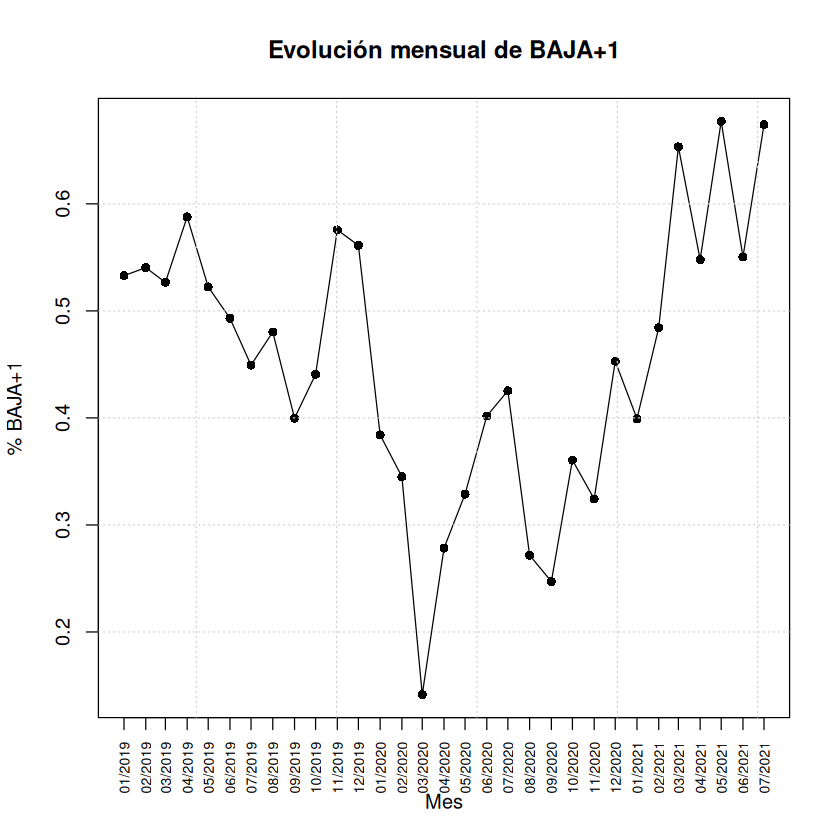

In [9]:
# ============================================================
# Gráfico BAJA+1
# ============================================================
plot(
  tb_grafico$fecha,
  tb_grafico$pct_baja1,
  type = "o",
  pch = 16,
  xaxt = "n",
  xlab = "Mes",
  ylab = "% BAJA+1",
  main = "Evolución mensual de BAJA+1"
)

axis.Date(
  1,
  at = tb_grafico$fecha,
  labels = format(tb_grafico$fecha, "%m/%Y"),
  las = 2,
  cex.axis = 0.7
)

grid()

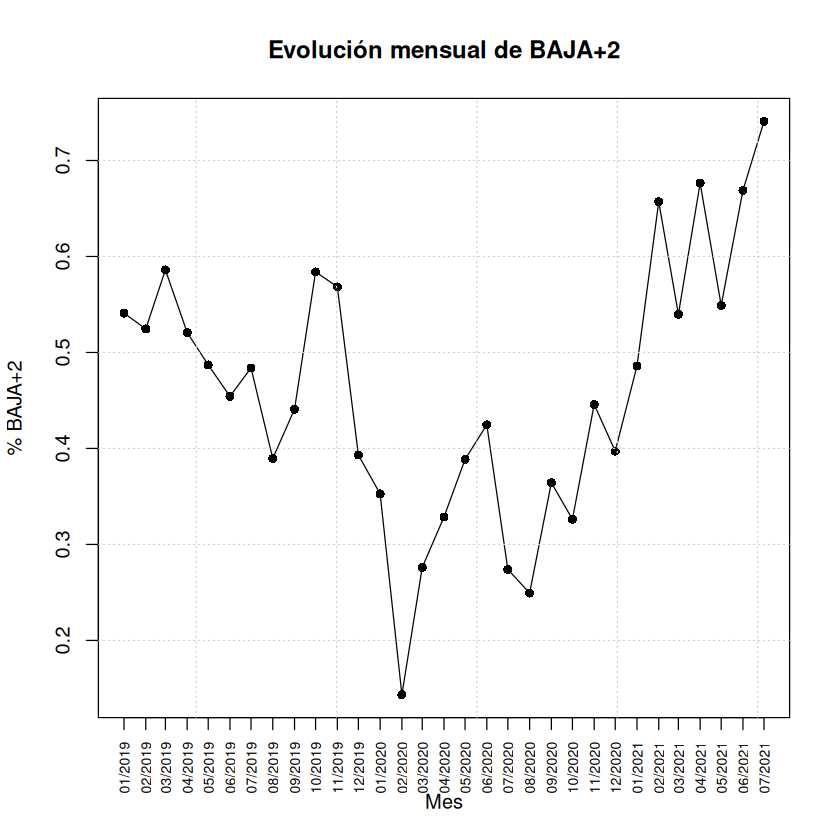

In [10]:
# ============================================================
# Gráfico BAJA+2
# ============================================================
plot(
  tb_grafico$fecha,
  tb_grafico$pct_baja2,
  type = "o",
  pch = 16,
  xaxt = "n",
  xlab = "Mes",
  ylab = "% BAJA+2",
  main = "Evolución mensual de BAJA+2"
)

axis.Date(
  1,
  at = tb_grafico$fecha,
  labels = format(tb_grafico$fecha, "%m/%Y"),
  las = 2,
  cex.axis = 0.7
)

grid()

In [11]:
# ============================================================
# ANALISIS TEMPORAL DE BAJA+1 Y BAJA+2
# Periodo analizado: 201901 - 202107
# ============================================================

tb_clases_mes <- dataset[
  !is.na(clase_ternaria) & foto_mes <= 202107,
  .(
    total = .N,
    baja1 = sum(clase_ternaria == "BAJA+1"),
    baja2 = sum(clase_ternaria == "BAJA+2")
  ),
  by = foto_mes
]

tb_clases_mes[
  ,
  `:=`(
    pct_baja1 = 100 * baja1 / total,
    pct_baja2 = 100 * baja2 / total
  )
]

setorder(tb_clases_mes, foto_mes)

# Convertimos foto_mes en una fecha real
tb_clases_mes[, fecha := as.Date(
  paste0(
    substr(foto_mes, 1, 4), "-",
    substr(foto_mes, 5, 6), "-01"
  )
)]

# Mostramos la tabla
tb_clases_mes

foto_mes,total,baja1,baja2,pct_baja1,pct_baja2,fecha
<int>,<int>,<int>,<int>,<dbl>,<dbl>,<date>
201901,24956,133,135,0.5329380,0.5409521,2019-01-01
201902,25165,136,132,0.5404331,0.5245380,2019-02-01
201903,25254,133,148,0.5266492,0.5860458,2019-03-01
201904,25346,149,132,0.5878640,0.5207922,2019-04-01
201905,25460,133,124,0.5223881,0.4870385,2019-05-01
201906,25755,127,117,0.4931081,0.4542807,2019-06-01
201907,26040,117,126,0.4493088,0.4838710,2019-07-01
201908,26443,127,103,0.4802783,0.3895171,2019-08-01
201909,26767,107,118,0.3997460,0.4408413,2019-09-01


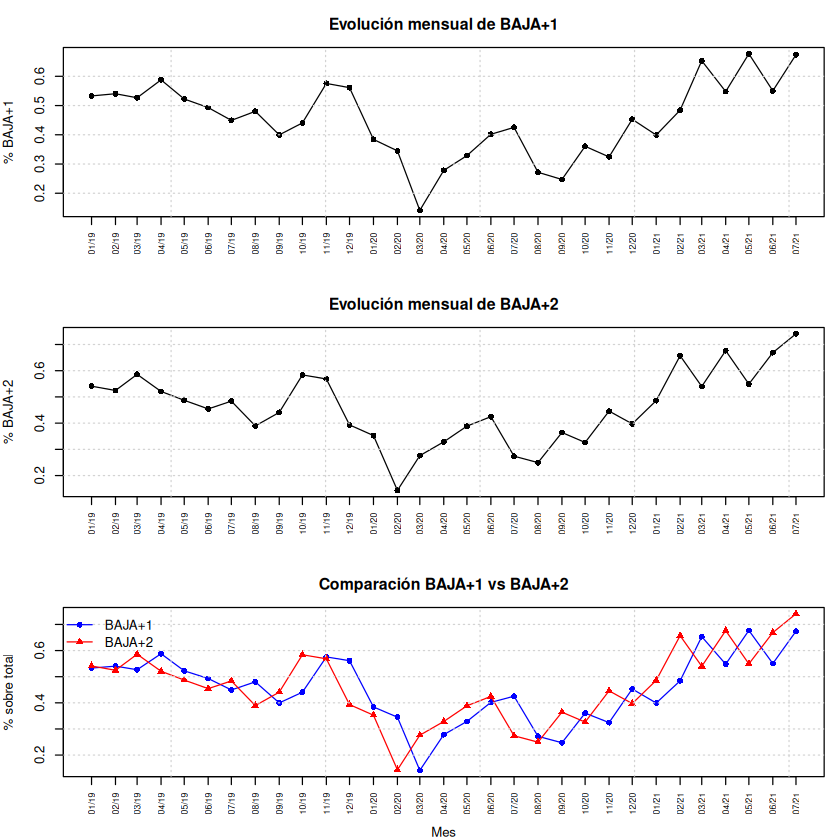

In [12]:
# ============================================================
# GRAFICOS
# ============================================================

# Tres gráficos en una misma ventana
par(
  mfrow = c(3, 1),
  mar = c(4, 4, 3, 1)
)

# ------------------------------------------------------------
# 1. BAJA+1
# ------------------------------------------------------------

plot(
  tb_clases_mes$fecha,
  tb_clases_mes$pct_baja1,
  type = "o",
  pch = 16,
  xaxt = "n",
  xlab = "",
  ylab = "% BAJA+1",
  main = "Evolución mensual de BAJA+1"
)

axis.Date(
  1,
  at = tb_clases_mes$fecha,
  labels = format(tb_clases_mes$fecha, "%m/%y"),
  las = 2,
  cex.axis = 0.65
)

grid()


# ------------------------------------------------------------
# 2. BAJA+2
# ------------------------------------------------------------

plot(
  tb_clases_mes$fecha,
  tb_clases_mes$pct_baja2,
  type = "o",
  pch = 16,
  xaxt = "n",
  xlab = "",
  ylab = "% BAJA+2",
  main = "Evolución mensual de BAJA+2"
)

axis.Date(
  1,
  at = tb_clases_mes$fecha,
  labels = format(tb_clases_mes$fecha, "%m/%y"),
  las = 2,
  cex.axis = 0.65
)

grid()


# ------------------------------------------------------------
# 3. BAJA+1 y BAJA+2 superpuestas
# ------------------------------------------------------------

ylim_comun <- range(
  tb_clases_mes$pct_baja1,
  tb_clases_mes$pct_baja2
)

plot(
  tb_clases_mes$fecha,
  tb_clases_mes$pct_baja1,
  type = "o",
  pch = 16,
  col = "blue",
  ylim = ylim_comun,
  xaxt = "n",
  xlab = "Mes",
  ylab = "% sobre total",
  main = "Comparación BAJA+1 vs BAJA+2"
)

lines(
  tb_clases_mes$fecha,
  tb_clases_mes$pct_baja2,
  type = "o",
  pch = 17,
  col = "red"
)

axis.Date(
  1,
  at = tb_clases_mes$fecha,
  labels = format(tb_clases_mes$fecha, "%m/%y"),
  las = 2,
  cex.axis = 0.65
)

grid()

legend(
  "topleft",
  legend = c("BAJA+1", "BAJA+2"),
  col = c("blue", "red"),
  pch = c(16, 17),
  lty = 1,
  bty = "n"
)

# Volvemos al modo normal de un gráfico por ventana
par(mfrow = c(1, 1))

### 9.5  Comparación estadística de los escenarios explorados

Se plantearon distintos escenarios a fin de evaluar la eventual incidencia de los meses afectados por la pandemia en el funcionamiento del sistema bancario, de manera tal que pudiesen perjudicar encontrar un modelo predictivo con máximas ganancias.

Cada escenario se exploró con una configuración básica de hiperparámetros del método lightGBM, corriéndose con 14 semillas a fin de minimizar el riesgo de cometer overfitting.

Por cada una de las semillas, se originaron 7 cortes donde los resultados se subieron a Kaggle. De esta manera, obtuvimos 7 valores de ganancias por cada semilla producto de estos 7 cortes.

Finalmente, para cada escenario, contamos con los resultados de ganancias de cada una de las 14 semillas empleadas tomando en cada caso la ganancia máxima entre los 7 cortes generados.

#### Escenarios evaluados:

#### **E0**: Se contemplan todos los meses registrados. 

#### Consideramos este escenario como la base de nuestro estudio.

#### - **Basados en los datos obtenidos de los informes del BCRA y nuestro sesgo personal**

#### **E1**: Quitamos del dataset abril, mayo y junio 2020.

#### **E2**: Quitamos del dataset marzo, abril, mayo y junio 2020.

#### - **Basados en las observaciones realizadas sobre el dataset en estudio**

#### **E3**: Quitamos del dataset febrero 2020.

#### **E4**: Quitamos del dataset febrero y marzo 2020.

#### **E5**: Quitamos del dataset enero, febrero y marzo 2020.







In [13]:
#### 9.5.1  Cargamos el dataset de resultados

In [14]:
setwd("/content/buckets/b1/exp")
tb_escenarios <- fread("resultados_escenarios_semillas.csv")

tb_escenarios[, escenario := factor(
  escenario,
  levels = c("E0", "E1", "E2", "E3", "E4", "E5")
)]

tb_escenarios

escenario,descripcion,semilla,ganancia
<fct>,<chr>,<int>,<int>
E0,Todos los meses,700001,85150
E0,Todos los meses,690506,83904
E0,Todos los meses,804528,84735
E0,Todos los meses,613037,85482
E0,Todos los meses,648983,82326
E0,Todos los meses,365305,84652
E0,Todos los meses,163687,85566
E0,Todos los meses,929304,88141
E0,Todos los meses,626029,86985


## 1. Análisis descriptivo de las ganancias por escenario

Como primera aproximación, se analizan las ganancias obtenidas para cada
escenario a través de las 14 semillas utilizadas.

Para cada escenario se calculan:

- media
- mediana
- desvío estándar
- mínimo
- máximo

De esta manera, no nos limitamos a comparar promedios de ganancias sino que también podremos ver la estabilidad y dispersión de los resultados ante cada semilla empleada.

También agregamos una columna a fines de comparar las ganancias de cada escenario con la ganancia de nuestro escenario de referencia.

In [15]:
resumen_escenarios <- tb_escenarios[, .(
  media   = mean(ganancia),
  mediana = median(ganancia),
  desvio  = sd(ganancia),
  minimo  = min(ganancia),
  maximo  = max(ganancia)
), by = escenario]

media_E0 <- resumen_escenarios[
  escenario == "E0",
  media
]

resumen_escenarios[
  , dif_media_E0 := media - media_E0
]

setorder(resumen_escenarios, -media)
resumen_escenarios

escenario,media,mediana,desvio,minimo,maximo,dif_media_E0
<fct>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>
E3,86355.21,85939.5,3268.995,79833,92544,1115.5000
E2,85731.64,85981.0,3088.584,79003,90467,491.9286
E5,85601.07,84527.0,4694.647,77923,93374,361.3571
E0,85239.71,85274.5,2409.858,80166,89636,0.0000
E1,85144.21,85939.0,3529.969,77674,91048,-95.5000
E4,85007.71,85191.5,2991.690,80830,91215,-232.0000


## 2. Gráfico: Boxplot

Pretendemos observar la distribución de cada escenario en función de lo obtenido en las 14 semillas empleadas.

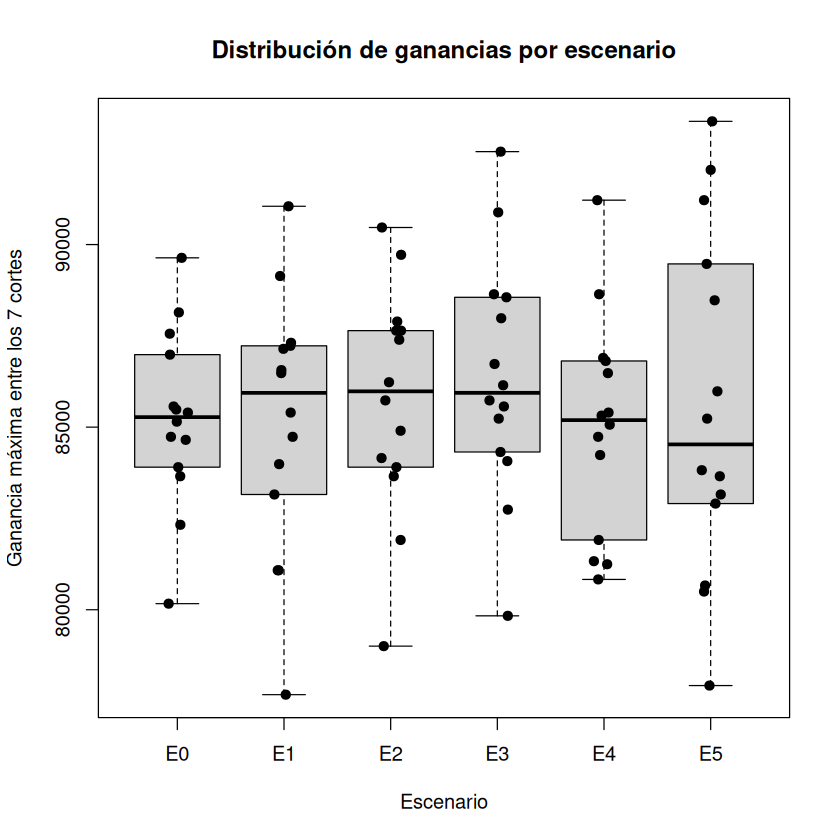

In [16]:
boxplot(
  ganancia ~ escenario,
  data = tb_escenarios,
  main = "Distribución de ganancias por escenario",
  xlab = "Escenario",
  ylab = "Ganancia máxima entre los 7 cortes",
  pch = 19
)

stripchart(
  ganancia ~ escenario,
  data = tb_escenarios,
  vertical = TRUE,
  method = "jitter",
  pch = 19,
  add = TRUE
)

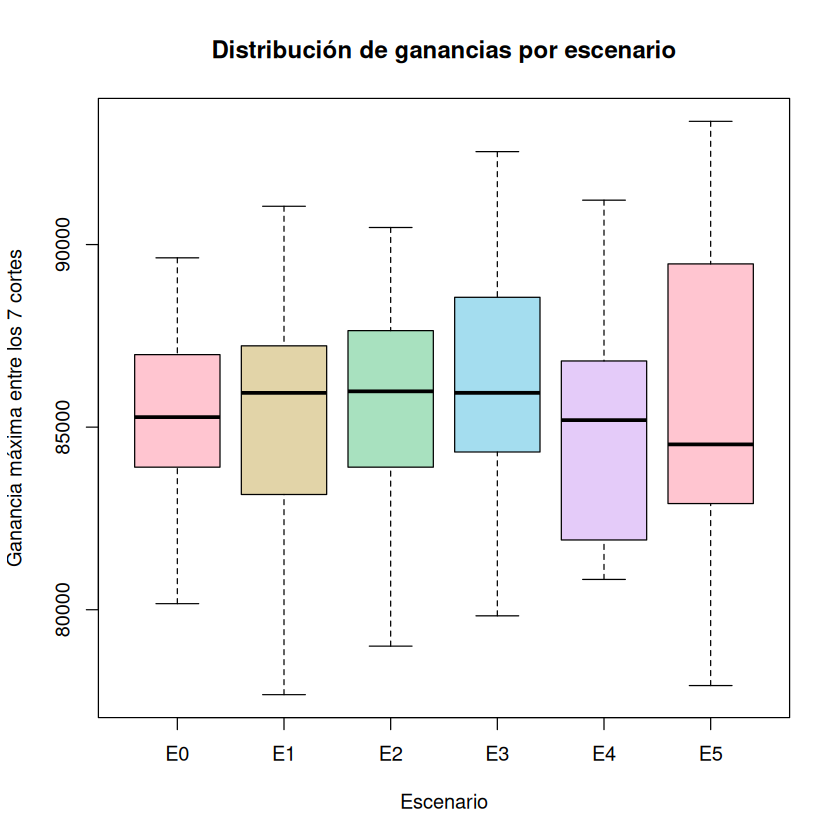

In [17]:
boxplot(
  ganancia ~ escenario,
  data = tb_escenarios,
  main = "Distribución de ganancias por escenario",
  xlab = "Escenario",
  ylab = "Ganancia máxima entre los 7 cortes",
  pch = 19,
  col = hcl.colors(5, "Pastel 1")
)

### Observaciones

- Si bien el escenario E3 vimos en la tabla que tiene el mayor valor media, las medianas entre E2 y E3 están muy próximas.

- En general, los boxplot se ven todos bastante superpuestos.

- El escenario E0, que tomamos como referencia, es el que presenta la menor dispersión, siendo los de mayor dispersión los E4 y E5.

## 2. Comparación estadística de los escenarios mediante Wilcoxon

Para determinar si las diferencias observadas entre las ganancias de los distintos escenarios escenarios son estadísticamente significativas, se aplica el test no paramétrico de rangos con signo de Wilcoxon.

Las comparaciones se realizan de manera pareada, debido a que todos los escenarios fueron evaluados utilizando exactamente las mismas 14 semillas.

Para cada par de escenarios se plantean las hipótesis:

- **H0**: no existen diferencias sistemáticas entre las ganancias obtenidas por ambos escenarios.
- **H1**: existen diferencias sistemáticas entre las ganancias obtenidas por ambos escenarios.

Consideramos un nivel de significación de α = 0.05.

### Iniciaremos comparando:

- E3 (con mayor media de ganancias)
- E0 (nuestro dataset de referencia).

In [18]:
ganancia_E0 <- tb_escenarios[escenario == "E0"][order(semilla), ganancia]

ganancia_E3 <- tb_escenarios[escenario == "E3"][order(semilla), ganancia]

wilcox.test(ganancia_E0, ganancia_E3, paired = TRUE, alternative = "two.sided", exact = FALSE)


	Wilcoxon signed rank test with continuity correction

data:  ganancia_E0 and ganancia_E3
V = 30, p-value = 0.1673
alternative hypothesis: true location shift is not equal to 0


#### En esta comparación obtenemos p-value = 0.1673 > 0.05, por lo que estadísticamente no hay evidencia que nos permita rechazar la hipótesis H0.

#### Esto es un inconveniente, porque entonces estadísticamente los dos escenarios no presentan diferencias y entonces las ganancias obtenidas tampoco las presentan. 

### Aplicamos Wilcoxon, en forma pareada, a todos los escenarios explorados.

Serán en total 15 comparaciones.


In [19]:
escenarios <- levels(tb_escenarios$escenario)

comparaciones <- combn(escenarios, 2, simplify = FALSE)

resultados_wilcoxon <- rbindlist(lapply(comparaciones, function(par) {
    esc1 <- par[1]
    esc2 <- par[2]

    x <- tb_escenarios[escenario == esc1][order(semilla), ganancia]
    y <- tb_escenarios[escenario == esc2][order(semilla), ganancia]

    test <- wilcox.test(x,y,paired = TRUE,alternative = "two.sided",exact = FALSE)

    data.table(escenario_1 = esc1,escenario_2 = esc2,p_value = test$p.value)}))

resultados_wilcoxon[, significativo := ifelse(p_value < 0.05,"SI","NO")]
setorder(resultados_wilcoxon, p_value)
resultados_wilcoxon

escenario_1,escenario_2,p_value,significativo
<chr>,<chr>,<dbl>,<chr>
E3,E4,0.1576066,NO
E0,E3,0.1672536,NO
E1,E3,0.3624494,NO
E0,E4,0.5292424,NO
E4,E5,0.5301580,NO
E1,E2,0.5508255,NO
E2,E3,0.6155185,NO
E3,E5,0.6376839,NO
E0,E1,0.7063581,NO


In [20]:
format(Sys.time(), "%a %b %d %X %Y")

[1] "Fri Sep 11 18:22:09 2026"